# 03_集成算法-极端随机森林

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱来聊聊极端随机森林\~

极端随机森林，全名叫 **Extremely Randomized Trees**，简称 **Extra Trees**，它是一个机器学习中的**集成算法**，用来做分类（比如判断邮件是不是垃圾邮件）或者回归（比如预测房价）的问题。

它跟随机森林很像，只不过它更「随机」，决策更「极端」一点。

当你要做一个重要决定，比如选哪部电影看。

你可能会：

- 问问几个朋友的意见
- 看看网上评分
- 再考虑自己的喜好

这就像是你用**多个意见综合判断**，而不是靠一个人说了算。机器学习中的**集成算法**，就是这个思路 - 把**很多个模型的结果合在一起**，来得出更准确的预测。

极端随机森林是由**很多棵决策树**组成的一片「森林」，这些树一起投票、做决定。

跟**随机森林**的区别是：

#### 1. 切分方式更随机

在建每棵树的时候，「随机森林」会找一个**最好的切法**来分数据，比如在哪个年龄点把人群分成两组最合理。

而「极端随机森林」会直接**随机选一个点切一刀**，不去计算哪一刀最优。

这种「随便切」的方式虽然看起来粗暴，但反而**降低了过拟合**（就是在训练集上表现很好，但在新数据上很差），让模型更有泛化能力。

#### 2. 多树多数决

每一棵树会给出一个自己的预测结果（比如“这封邮件是垃圾邮件”），最后所有树投票，得出最终答案。

就像一群人投票决定看哪部电影，大多数人说《疯狂星期五》，那我们就看这部。

**跟随机森林有啥不同？**

| 项目 | 随机森林 | 极端随机森林 |
|-|-|-|
| 特征选择 | 随机选一部分特征，然后找最优切分点 | 随机选特征+随机选切分点 |
| 偏差 | 稍微低一点 | 稍微高一点 |
| 方差 | 稍微高一点 | 更低，稳定性更好 |
| 训练速度 | 慢一些 | 更快，因为不找“最佳”切分点 |

**一句话总结**：极端随机森林就是一群"随机切菜"的决策树，虽然它们每一棵树都不是最聪明的，但靠数量多、方向广，投票起来还挺靠谱。

## 原理详解

### 整体思想

用多个**完全随机构建的决策树**组成一个模型，每棵树的预测都不太靠谱，但整体平均（或投票）后会非常强大。

相比随机森林，它进一步**增加了切分点选择上的随机性**，从而进一步减少过拟合，降低模型方差。

设我们有一个数据集：

- 输入特征：$X = \{x_1, x_2, \dots, x_n\}$，其中 $x_i \in \mathbb{R}^d$
- 标签：$Y = \{y_1, y_2, \dots, y_n\}$
- 样本数：$n$
- 特征维度：$d$

我们要学得一个模型 $\hat{f}(x)$ 来逼近真实函数 $f(x)$，使得在新样本上的期望误差最小。

### Extra Trees 的数学建模与推理

#### 1. 集成学习框架

Extra Trees 属于并行集成方法（不像Boosting是串行的），假设我们训练了 $M$ 棵树，每棵树的输出为 $\hat{f}_m(x)$，则最终模型为：

- 对于**回归问题**（平均输出）：


$$
\hat{f}(x) = \frac{1}{M} \sum_{m=1}^{M} \hat{f}_m(x)
$$


- 对于**分类问题**（多数投票）：


$$
\hat{f}(x) = \arg\max_{y \in \mathcal{Y}} \sum_{m=1}^{M} \mathbb{I}[\hat{f}_m(x) = y]
$$


其中 $\mathbb{I}$ 是指示函数，表示是否投给类别 $y$。

#### 2. 单棵决策树的构建

与传统 CART 树（Classification And Regression Tree）不同，Extra Trees 在**构造每个内部节点时采用以下两个极端随机化策略**：

**策略一：随机选择特征子集**

- 对每个节点，随机选出 $k \le d$ 个特征，而不是使用所有特征。
- 通常 $k = \sqrt{d}$（分类） 或 $k = d/3$（回归）

**策略二：对每个特征，随机选取切分点**

- 对于选出的每一个特征 $j$：

  - 不再去寻找使目标函数（如 Gini、信息增益、MSE）最优的切分点。
  - 而是从该特征在当前节点的数据中的取值范围 $[a_j, b_j]$ 上**均匀随机采样一个切分点** $\theta_j \sim \mathcal{U}(a_j, b_j)$
- 然后计算这些随机切分点的划分质量，选出效果最好的那个特征 + 切分点组合。

#### 3. 划分质量评估

虽然切分点是随机生成的，但最终我们还是会从这些随机切分中**选出一个划分效果最好的**。

常见划分标准：

对于**分类问题**：使用**基尼指数（Gini Index）**

- 当前节点 impurity:  
$G(t) = 1 - \sum_{c \in \mathcal{C}} p_{c}^{2}$  
其中 $p_c$ 是当前节点中类别 $c$ 的样本比例。
- 划分后的 impurity gain：  
$\Delta G = G(t) - \left( \frac{N_L}{N} G(t_L) + \frac{N_R}{N} G(t_R) \right)$

选择使 $\Delta G$ 最大的切分。

对于**回归问题**：使用**均方误差（MSE）**

- 当前节点 MSE：  
$MSE(t) = \frac{1}{N} \sum_{i=1}^{N}(y_i - \bar{y})^2$
- 划分后的误差下降量：  
$\Delta MSE = MSE(t) - \left( \frac{N_L}{N} MSE(t_L) + \frac{N_R}{N} MSE(t_R) \right)$

最终在随机采样的切分点中，选择让 impurity reduction（如 Gini 或 MSE）最大的组合。

### Extra Trees 的完整算法流程

1. **输入数据集** $(X, Y)$，设定树的数量 $M$，每个节点随机选取特征数 $k$，以及最小样本数、最大深度等参数。
2. **对于每棵树** $m = 1, 2, ..., M$**：**
3. a. 不进行 bootstrap 采样（默认使用整个训练集）
4. b. 从根节点开始递归构建树：

   - 对当前节点，若样本数 < 最小阈值或 impurity 很小，则停止切分，设为叶子节点。
   - 随机选取 $k$ 个特征
   - 对每个特征 $j$：
   
     - 从特征取值范围中**随机采样一个切分点** $\theta_j$
   - 计算所有候选切分点对应的 impurity reduction，选出最佳切分特征和切分点。
   - 用这个切分点将当前样本划分为左右子节点
   - 对左右子节点递归进行以上步骤
5. 所有 $M$ 棵树构建完成，组成一个 Extra Trees 模型
6. **预测阶段**：

   - 对于输入 $x$，将其输入所有 $M$ 棵树，得到每棵树的预测 $\hat{f}_m(x)$
   - 对于分类：多数投票
   - 对于回归：取平均值

### 偏差-方差

Extra Trees 通过更强的随机性，来达到**降低模型方差**的目标。

| 项 | Extra Trees | Random Forest |
|-|-|-|
| 偏差 | 稍高 | 稍低 |
| 方差 | 更低（更稳定） | 稍高（更容易过拟合） |

这是因为：Extra Trees 不进行 bootstrap，更加稳定，切分点完全随机，降低模型复杂度和过拟合风险。

## 完整案例

我们选用 sklearn 自带的乳腺癌（Breast Cancer）数据集，进行数据探索、预处理、模型训练、模型评估、特征重要性分析以及超参数优化。

#### 数据导入与探索性数据分析

加载乳腺癌数据集。数据集包含 569 个样本和 30 个特征，每个样本对应一个二分类标签（良性或恶性）。

我们将对数据集进行初步统计分析，如分布、相关性热力图等。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, cross_val_score
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
import warnings


# 加载数据集
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# 数据集基本信息展示
print("数据集样本数：", X.shape[0])
print("数据集特征数：", X.shape[1])
print("目标变量类别：", np.unique(y))
print("\n数据描述：\n", X.describe())

数据集样本数： 569
数据集特征数： 30
目标变量类别： [0 1]

数据描述：
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380     

- **数据维度**：本数据集包含 569 个样本，每个样本 30 个特征，目标变量为二分类（0：恶性，1：良性）。
- **统计描述**：通过 `describe()` 方法，我们能查看各特征的均值、标准差、最小值、最大值等统计信息。
- **相关性分析**：后续将通过热力图分析各特征间的相关性，寻找高相关性特征，为特征选择或降维提供依据。

接下来，绘制部分特征的分布图以及特征相关性热力图，便于直观理解数据分布情况和变量之间的相互关系。

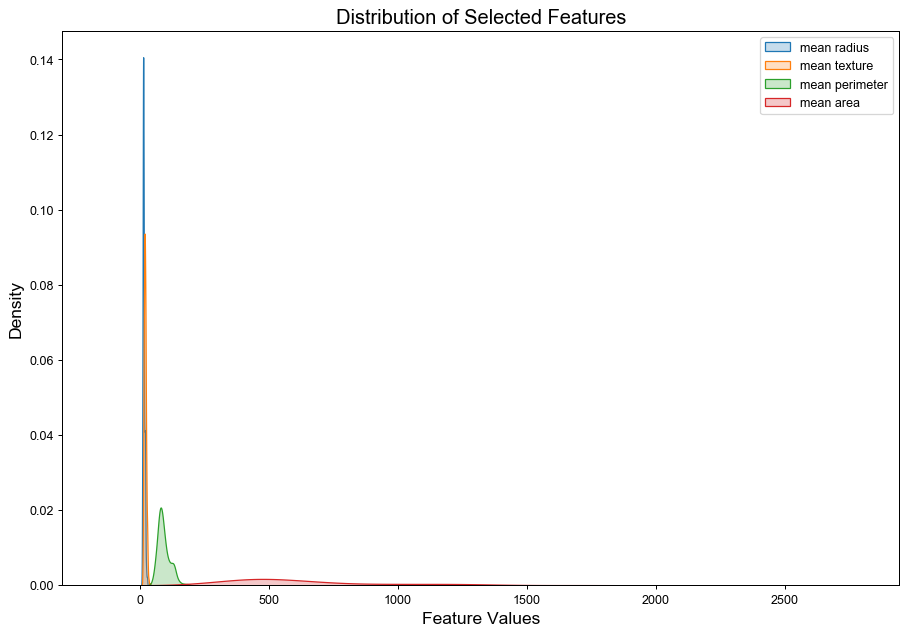

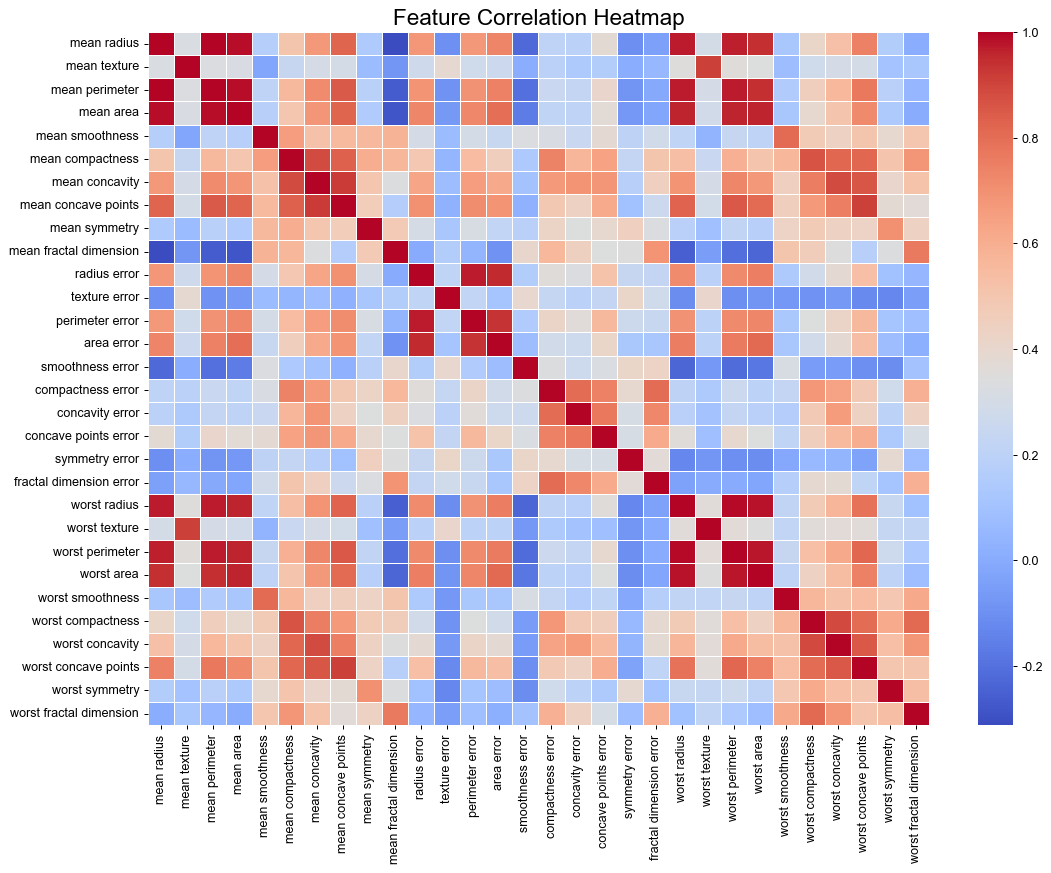

In [3]:
# 绘制部分特征的分布情况
plt.figure(figsize=(12, 8))
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
for feature in features_to_plot:
    sns.kdeplot(X[feature], fill=True, label=feature)
plt.title("Distribution of Selected Features", fontsize=16)
plt.xlabel("Feature Values", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend()
plt.show()

# 绘制特征相关性热力图
plt.figure(figsize=(14, 10))
corr = X.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=18)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_003.png)

1. **分布图**：显示了选定特征的概率密度分布，帮助我们判断数据是否存在偏态、异常值或多峰分布现象。
2. **相关性热力图**：展示了不同特征之间的线性相关性。相关性高的特征可能存在冗余信息，对模型构建时可考虑降维或特征选择，减少过拟合风险。

![原文参考图，当前结果见代码输出](attachments/img_004.png)

### 数据预处理与划分

在进行模型训练前，需要对数据集进行划分，将数据分为训练集和测试集。这里我们使用 70% 的数据作为训练集，30% 的数据作为测试集。

此外，对于某些模型（如基于距离度量的模型）有必要对数据进行标准化，但在树模型中不强制要求标准化处理。

In [4]:
# 数据划分：70% 训练集，30% 测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("训练集样本数：", X_train.shape[0])
print("测试集样本数：", X_test.shape[0])

训练集样本数： 398
测试集样本数： 171


- **数据划分**：将数据划分为训练集和测试集可以有效评估模型的泛化能力，防止模型在训练数据上过拟合。
- **stratify 参数**：保持类别分布一致，有助于平衡各类别比例，确保模型训练和测试数据分布相似。

### 模型训练 - Extra Trees Classifier

接下来，我们构造极端随机森林分类器，并训练模型。Extra Trees 在构建过程中对特征选择和划分阈值进行随机采样，因此比传统决策树具有更高的鲁棒性和泛化能力。

这里我们先采用默认参数训练模型，并对其进行初步评估。

In [5]:
# 构建并训练 Extra Trees 分类器
etc = ExtraTreesClassifier(random_state=42)
etc.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = etc.predict(X_test)

#### 模型初步评估

我们使用混淆矩阵、分类报告以及准确率等指标来评估模型性能。

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96        64
           1       0.96      0.99      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171

Accuracy: 0.9707602339181286


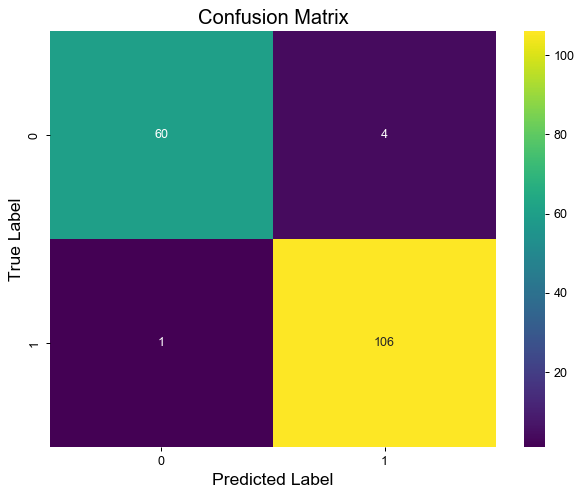

In [6]:
# 输出分类报告和准确率
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# 绘制混淆矩阵热力图
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='viridis', cbar=True)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_005.png)

- **分类报告**：详细展示了每个类别的精确率（precision）、召回率（recall）和 F1 分数，帮助我们了解模型在不同类别上的表现。
- **混淆矩阵**：通过混淆矩阵，我们能直观了解模型的预测错误分布，判断是否存在偏向某一类别的情况。
- **准确率**：整体反映模型在测试集上的预测准确性，是评估分类模型的重要指标之一。

### ROC 曲线与 AUC 分析

为了进一步评估模型在不同阈值下的分类性能，我们绘制 ROC 曲线并计算 AUC（曲线下面积）。

ROC 曲线展示了在不同分类阈值下模型的真阳性率（TPR）和假阳性率（FPR），AUC 值则衡量了模型总体的判别能力。

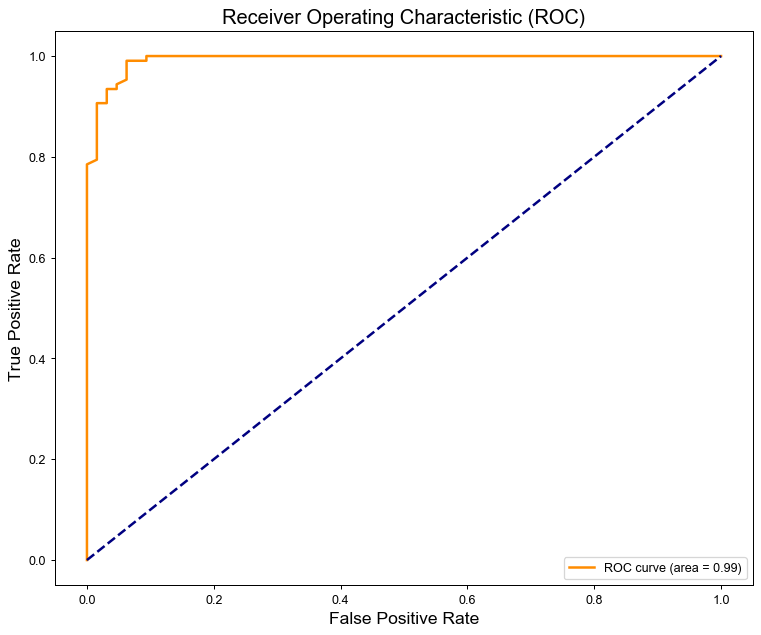

In [7]:
# 计算预测概率
y_proba = etc.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 绘制 ROC 曲线
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=16)
plt.legend(loc="lower right")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_006.png)

- **ROC 曲线**：通过绘制 ROC 曲线，我们可以了解模型在不同阈值下的敏感性和特异性。
- **AUC 值**：AUC 值越接近 1，模型的判别能力越强；本例中若 AUC 值较高，则说明模型对乳腺癌良恶性分类较为准确。

### 学习曲线分析

学习曲线展示了模型在训练集和交叉验证集上的性能随训练样本数变化的情况，有助于判断模型是否存在欠拟合或过拟合现象，以及是否需要增加数据量。

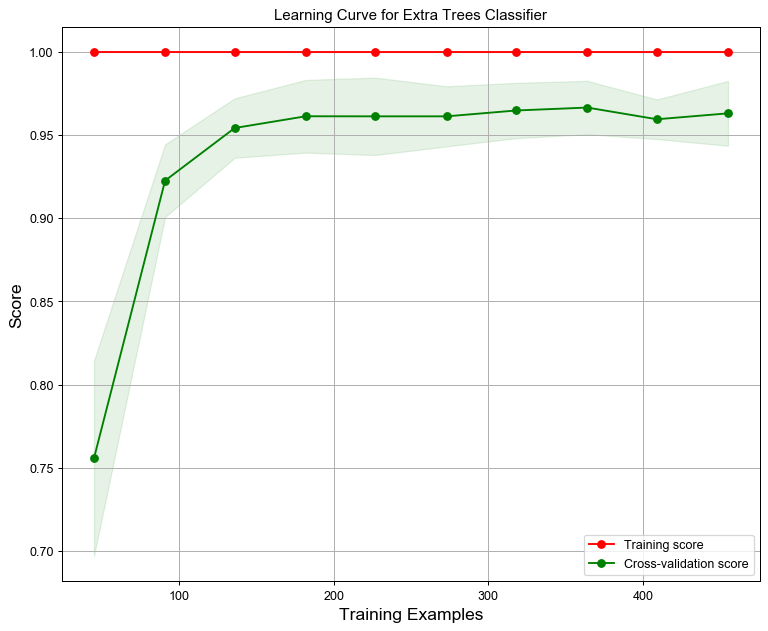

In [8]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5, n_jobs=1, train_sizes=np.linspace(.1, 1.0, 10)):
    """
    绘制学习曲线的函数
    title: 图表标题
    X: 特征数据
    y: 标签数据
    ylim: y轴取值范围
    cv: 交叉验证次数
    n_jobs: 并行数
    train_sizes: 训练样本比例
    """
    plt.figure(figsize=(10, 8))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training Examples", fontsize=14)
    plt.ylabel("Score", fontsize=14)

    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std  = np.std(train_scores, axis=1)
    test_scores_mean  = np.mean(test_scores, axis=1)
    test_scores_std   = np.std(test_scores, axis=1)

    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    plt.show()

# 绘制 Extra Trees 分类器的学习曲线
plot_learning_curve(etc, "Learning Curve for Extra Trees Classifier", X, y)

![原文参考图，当前结果见代码输出](attachments/img_007.png)

- **学习曲线**：通过观察训练集和交叉验证集的分数变化趋势，可以判断模型是否出现欠拟合（两条曲线均较低且重合）或者过拟合（训练分数远高于验证分数）。
- **数据利用情况**：如果两条曲线在样本数增加后趋于平稳，则说明模型性能已达到饱和，可能需要其他手段（如更复杂模型或特征工程）来提高性能。

### 特征重要性分析

极端随机森林内置特征重要性评估机制，通过评估每个特征在决策树中的使用频率和分裂效果，我们可以得到各特征的重要性排序。该分析有助于理解模型内部机制，也能辅助后续特征筛选。

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9667/3126736933.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")


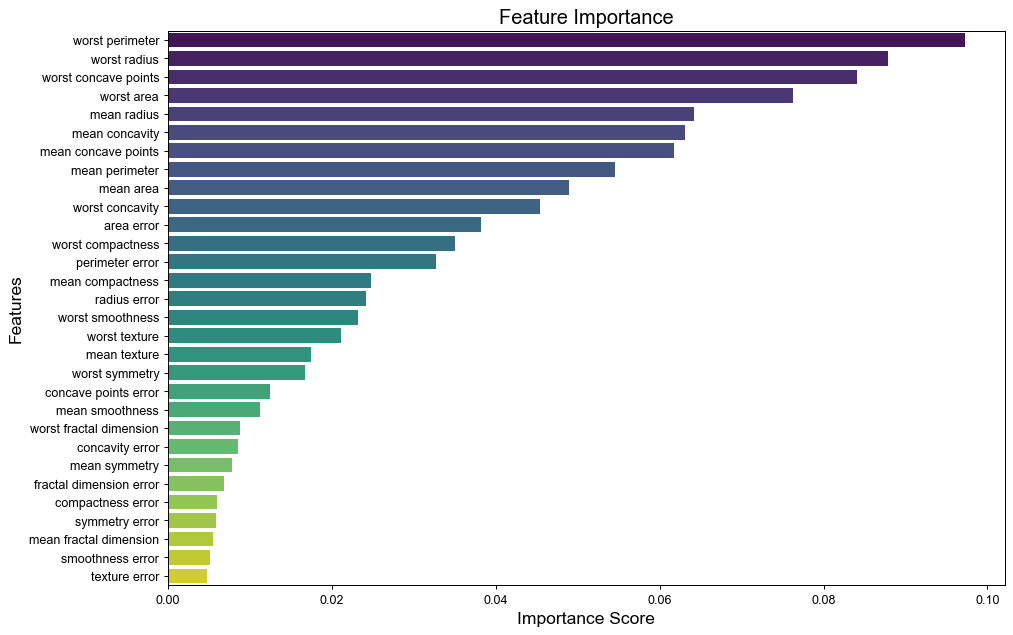

Top 10 important features:
 worst perimeter         0.097266
worst radius            0.087892
worst concave points    0.084140
worst area              0.076324
mean radius             0.064151
mean concavity          0.063129
mean concave points     0.061775
mean perimeter          0.054559
mean area               0.048923
worst concavity         0.045458
dtype: float64


In [9]:
# 获取各特征的重要性
feature_importances = pd.Series(etc.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# 绘制特征重要性条形图
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.title("Feature Importance", fontsize=16)
plt.xlabel("Importance Score", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.show()

# 输出前 10 个重要特征
print("Top 10 important features:\n", feature_importances.head(10))

![原文参考图，当前结果见代码输出](attachments/img_008.png)

- **特征排序**：通过条形图直观展示每个特征对模型预测结果的贡献，重要性越高说明该特征在决策过程中发挥的作用越大。
- **特征筛选**：若发现部分特征重要性较低，可以考虑在后续迭代中进行特征降维或剔除无关变量，降低模型复杂度、提高泛化能力。

### 模型优化与超参数调优

虽然初步训练结果不错，但通过调节超参数可以进一步优化模型。

Extra Trees 模型的主要超参数包括：

- **n_estimators**：决策树数量
- **max_depth**：决策树最大深度
- **min_samples_split**：分裂内部节点所需的最小样本数
- **min_samples_leaf**：叶子节点最少样本数
- **max_features**：每个分裂时考虑的最大特征数

我们使用 GridSearchCV 对上述参数进行网格搜索调优，找到最优参数组合。

In [10]:
# 定义超参数网格
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# 实例化 Extra Trees 分类器，并进行网格搜索
etc_grid = ExtraTreesClassifier(random_state=42)
grid_search = GridSearchCV(estimator=etc_grid, param_grid=param_grid, cv=5, n_jobs=1, scoring='accuracy', verbose=1, error_score='raise')
grid_search.fit(X_train, y_train)

# 输出最佳参数及其对应的得分
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# 使用最佳参数重新训练模型
best_etc = grid_search.best_estimator_
best_etc.fit(X_train, y_train)
y_pred_best = best_etc.predict(X_test)
print("Optimized Model Accuracy:", accuracy_score(y_test, y_pred_best))

Fitting 5 folds for each of 32 candidates, totalling 160 fits


Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 50}
Best CV Score: 0.9749367088607596
Optimized Model Accuracy: 0.9473684210526315


![原文参考图，当前结果见代码输出](attachments/img_009.png)

- **网格搜索**：通过在预设的参数空间内搜索最佳组合，我们可以优化模型性能，找到使模型在交叉验证上得分最高的参数设置。
- **调优结果**：输出最佳参数组合以及优化后的模型在测试集上的准确率，从而验证调优效果是否显著提升模型表现。

![原文参考图，当前结果见代码输出](attachments/img_010.png)

### 模型进一步评估与对比

在获得最优模型后，我们不仅对其在测试集上的表现进行评估，还可以对比初始模型与优化后模型在各项指标上的表现差异。例如，利用 ROC 曲线、混淆矩阵、学习曲线等多角度进行对比分析，确保调优后的模型具有更好的泛化能力和稳定性。

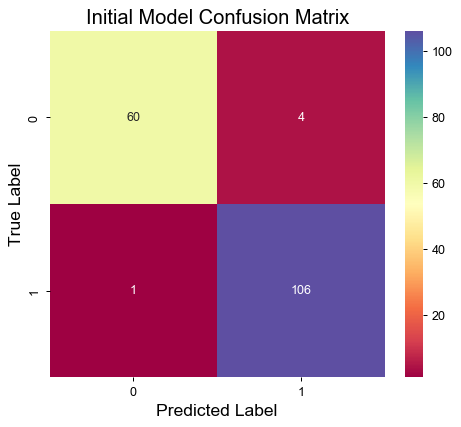

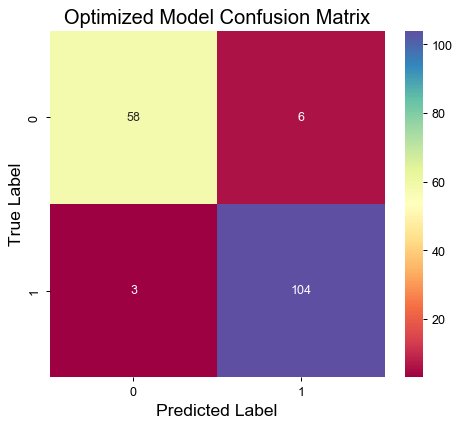

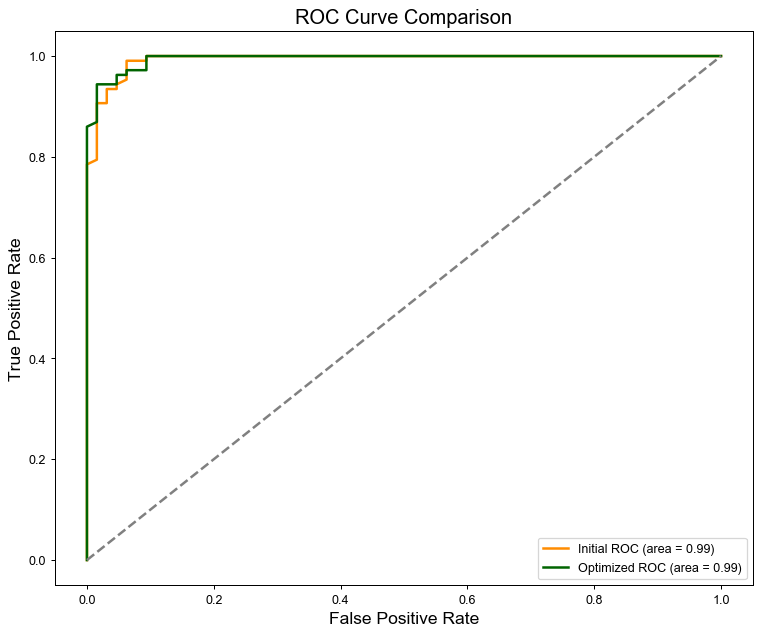

In [11]:
# 绘制优化前后的混淆矩阵对比
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Spectral')
    plt.xlabel("Predicted Label", fontsize=14)
    plt.ylabel("True Label", fontsize=14)
    plt.title(title, fontsize=16)
    plt.show()

# 优化前模型混淆矩阵
conf_mat_initial = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mat_initial, "Initial Model Confusion Matrix")

# 优化后模型混淆矩阵
conf_mat_optimized = confusion_matrix(y_test, y_pred_best)
plot_confusion_matrix(conf_mat_optimized, "Optimized Model Confusion Matrix")

# 对比 ROC 曲线
y_proba_best = best_etc.predict_proba(X_test)[:, 1]
fpr_best, tpr_best, _ = roc_curve(y_test, y_proba_best)
roc_auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Initial ROC (area = %0.2f)' % roc_auc)
plt.plot(fpr_best, tpr_best, color='darkgreen', lw=2, label='Optimized ROC (area = %0.2f)' % roc_auc_best)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve Comparison', fontsize=16)
plt.legend(loc="lower right")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_011.png)

- **混淆矩阵对比**：通过对比初始模型与优化后模型的混淆矩阵，可以直观看出优化后模型在各类别上的预测错误数是否减少。
- **ROC 曲线对比**：通过 ROC 曲线和 AUC 值的比较，检验优化后的模型是否在整体判别能力上有提升。

我们从数据探索、预处理、模型训练、模型评估、特征重要性分析到超参数调优，全面演示了如何利用极端随机森林（Extra Trees）进行乳腺癌数据分类。

## 模型分析

### 极端随机森林模型的优缺点

**优点**：

- **训练速度快**：极端随机森林在构造决策树时引入了更多随机性，减少了寻找最佳分裂点的时间，因此在大数据集上训练速度通常较快。
- **抗过拟合能力强**：通过对样本和特征的随机抽样以及随机阈值的选择，模型在一定程度上降低了过拟合风险，具有较好的泛化性能。
- **特征重要性评估**：该模型内置特征重要性评估机制，可以直观地反映每个特征对决策的贡献，便于后续特征筛选与工程。
- **鲁棒性**：在存在噪声数据或存在缺失值的场景下，决策树集成方法通常比单棵树更为稳定和鲁棒。
- **无需数据归一化**：与基于距离或内积的模型不同，决策树算法对数据的缩放和归一化不敏感，可以直接处理原始数据。

**缺点**：

- **解释性相对较弱**：虽然可以输出特征重要性，但整体模型为“黑箱”结构，单棵树的分裂路径较难解释整个模型的预测过程。
- **内存消耗较大**：构建大量树模型时，可能会消耗较多内存资源，尤其是在数据维度和样本数量较大时。
- **参数调优复杂**：虽然模型具有很多超参数（例如树的数量、最大深度、最小分裂样本数等），但这些参数之间的相互影响较大，调优过程可能较为耗时。
- **对异常点敏感**：决策树在某些情况下对异常值较为敏感，尤其是当异常点在少数决策树中引入错误分裂时，可能会影响整体模型表现。

### 与相似算法的对比

下面通过表格对比「极端随机森林」与其他几种常用的集成算法，以便从多个维度了解其优势与不足。

| **算法名称** | **构造方式** | **训练速度** | **泛化能力** | **参数调优难度** | **特征重要性评估** |
|-|-|-|-|-|-|
| **极端随机森林** | 随机抽样样本与特征，随机阈值分裂 | 较快 | 较强 | 中等偏高 | 内置，直观 |
| **随机森林** | 采用Bootstrap采样、随机选择特征进行分裂 | 较快 | 较强 | 中等 | 内置，直观 |
| **梯度提升决策树（GBDT）** | 依次训练弱学习器，逐步纠正前一模型的错误 | 较慢 | 强（调优得当时） | 较高 | 通过特征分裂频次评估 |
| **XGBoost** | 改进GBDT，引入正则化项，加速分裂寻找及并行计算 | 较快（相较于GBDT） | 很强（调优得当时） | 较高 | 内置，直观 |
| **LightGBM** | 基于直方图的决策树算法，专为大规模数据设计 | 很快 | 很强 | 较高 | 内置，直观 |

- **训练速度**：极端随机森林通常在构造树时速度较快，因为它采用随机阈值，而不像其他方法那样计算最优分裂。
- **泛化能力**：集成方法普遍具有较强的泛化能力，但在数据量足够大且噪声较多的情况下，随机化机制能有效降低过拟合风险。
- **参数调优难度**：GBDT、XGBoost 和 LightGBM 等算法具有更多参数，调优过程相对复杂；而极端随机森林和随机森林参数相对较少，但调优空间依然存在。
- **特征重要性评估**：几乎所有树模型都内置了特征重要性评估，便于理解和解释模型决策。

### 何时优选极端随机森林，何时考虑其他算法

**优选极端随机森林的情况**：

- **大规模数据处理**：在数据量较大、特征维度较高的情况下，由于其训练速度快且具有较强的鲁棒性，极端随机森林是一种理想选择。
- **对模型稳定性要求高**：当任务中噪声较多或样本质量不高时，该模型的随机化策略可以帮助提高整体稳定性。
- **需要快速迭代**：在开发和调试阶段，能够迅速得到模型评估结果，便于后续的特征筛选和算法改进。
- **解释性需求有限**：当重点在于提高预测准确性，而对模型解释要求不高时，极端随机森林可作为首选算法。

**考虑其他算法的情况**：

- **追求极致性能**：当对模型预测性能有更高要求，并且能够投入更多计算资源进行调参时，XGBoost、LightGBM 或 GBDT 可能提供更高的精度。
- **解释性要求较高**：如果项目需要对模型内部决策路径进行详细解释或需要稀疏性较高的特征选择，则可能需要考虑更易解释的模型或结合其他解释性方法。
- **资源受限的场景**：在内存和计算资源受限的场景下，有时极端随机森林可能因大量树模型带来较高内存消耗，此时可以考虑简化的决策树或经过剪枝的随机森林。
- **不平衡数据处理**：当数据存在严重类别不平衡问题时，可能需要结合专门处理不平衡问题的算法或引入样本加权、欠采样/过采样策略，部分提升模型效果。

以上讨论，咱们可以看出极端随机森林在速度、稳定性和特征重要性评估上具备明显优势，适用于大部分分类和回归任务。与此同时，在需要极致预测精度、对解释性要求较高、或资源受限的场景中，可根据实际情况考虑使用其他集成算法或模型进行补充和对比。